In [1]:
# %%
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
Directory = r'D:\Ring_MIT_Sid_chip\scripts\directional_coupler'
data_path = Path(r'D:\Ring_MIT_Sid_chip\results_data')
os.chdir(Directory)
pwd = os.getcwd()
print(pwd)

D:\Ring_MIT_Sid_chip\scripts\directional_coupler


In [2]:

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  
# %matplotlib qt
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")

LumFileName = "DirectionalCoupler_radii_sweep.lms" # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()

# %%
f.switchtolayout()


Starting new Lumerical MODE session...


In [3]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------

LambdaStart    = 1530E-9
LambdaStop     = 1570E-9

Width          = 1500E-9
Height         = 200E-9
ArcRadius      = 60E-6
Gap            = 600E-9
XLength        = 10E-6
YLength        = 10E-6
CouplingLength = 30E-6

Material       = "Si3N4 (Silicon Nitride) - Luke"
Index          = 2; #optional

BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 500E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(1000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")

Frequency Points: 40000


Top y at coupling (center): -15.75
Bot y at coupling (center): 15.75
Actual gap: -31.5


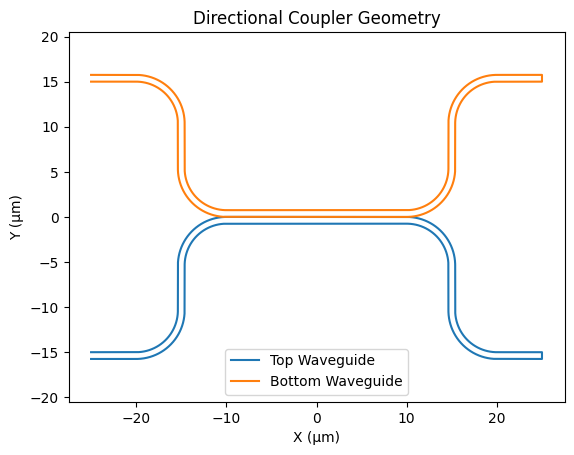

In [4]:
def u_bend(width=0.5, length_in=5.0, vertical_length=5.0,gap=2.0,
            coupling_length=10.0, arc_radius=5.0,
            start_y=0.0, direction=1, points=50):
    y_offset = 2*(vertical_length+ arc_radius)
    def reverse(x, y):
        return x[::-1], y[::-1]

    def arc_90(x0, y0, R, start='x'):
        t = np.linspace(0, np.pi/2, points)

        if start == 'x':          # horizontal → vertical
            x = x0 + R * np.sin(t)
            y = y0 - direction * R * (1 - np.cos(t))
        elif start == 'y':        # vertical → horizontal
            x = x0 + R * (1 - np.cos(t))
            y = y0 - direction * R * np.sin(t)

        return x, y

    # Input straight + first 90°
    x1 = np.linspace(0, length_in, points)
    y1 = np.full(points, start_y)
    x2, y2 = arc_90(x1[-1], y1[-1], arc_radius, 'x')

    # Vertical straight
    y_vert_start = y2[-1]
    y_vert_end   = y_vert_start - direction * vertical_length
    y_vert = np.linspace(y_vert_start, y_vert_end, 20)
    x_vert = np.full_like(y_vert, x2[-1])

    # Second 90°
    x3, y3 = arc_90(x_vert[-1], y_vert[-1], arc_radius, 'y')

    # Coupling region
    x4 = np.linspace(x3[-1], x3[-1] + coupling_length, 30)
    y4 = np.full_like(x4, y3[-1])

    # Mirror for output side
    x5, y5 = reverse(x4[-1] + (x4[-1] - x3), y3)
    x6, y6 = reverse(x5[-1] + (x2[-1] - x2), y2)
    x7, y7 = reverse(x6[-1] + (x1[-1] - x1), y1)

    # Combine centerline
    x_center = np.concatenate([x1, x2, x_vert, x3, x4, x5, x6, x7])
    y_center = np.concatenate([y1, y2, y_vert, y3, y4, y5, y6, y7])

    x_center -= (x_center.min() + x_center.max()) / 2
    coupling_y = y4[0]
    y_center -= coupling_y
    y_center += (gap/2 + width/2) * direction

    # Then compute offsets and return

    # Normal offset (parallel curves)
    dx = np.gradient(x_center)
    dy = np.gradient(y_center)
    norm = np.sqrt(dx**2 + dy**2)
    norm[norm == 0] = 1.0
    nx = -dy / norm
    ny =  dx / norm

    x_top = x_center + nx * width/2
    y_top = y_center + ny * width/2
    x_bot = x_center - nx * width/2
    y_bot = y_center - ny * width/2

    return np.column_stack([
        np.concatenate([x_top, x_bot[::-1]]),
        np.concatenate([y_top, y_bot[::-1]])
    ])

def directional_coupler(gap, width=0.75, length_in=5.0, vertical_length=10.0,
                        coupling_length=10.0, arc_radius=5.0):  
    top = u_bend(width=width, length_in=length_in, vertical_length=vertical_length, gap=gap,
                coupling_length=coupling_length, arc_radius=arc_radius, start_y=0, direction=-1)
    bot = u_bend(width=width, length_in=length_in, vertical_length=vertical_length, gap=gap,
                coupling_length=coupling_length, arc_radius=arc_radius, start_y=0, direction=1)
    return top, bot
top, bot = directional_coupler(gap=0.0, width=0.75, length_in=5.0, vertical_length=5.0,
                                coupling_length=10.0, arc_radius=5.0)
print("Top y at coupling (center):", top[:,1].min())
print("Bot y at coupling (center):", bot[:,1].max())
print("Actual gap:", top[:,1].min() - bot[:,1].max())
plt.figure()
plt.plot(top[:,0], top[:,1], label='Top Waveguide')
plt.plot(bot[:,0], bot[:,1], label='Bottom Waveguide')
plt.axis('equal')
plt.title('Directional Coupler Geometry')
plt.xlabel('X (µm)')
plt.ylabel('Y (µm)')
plt.legend()
plt.show()


R=40µm | η=97.34% | Loss=2.11dB| eta variation=2.73%


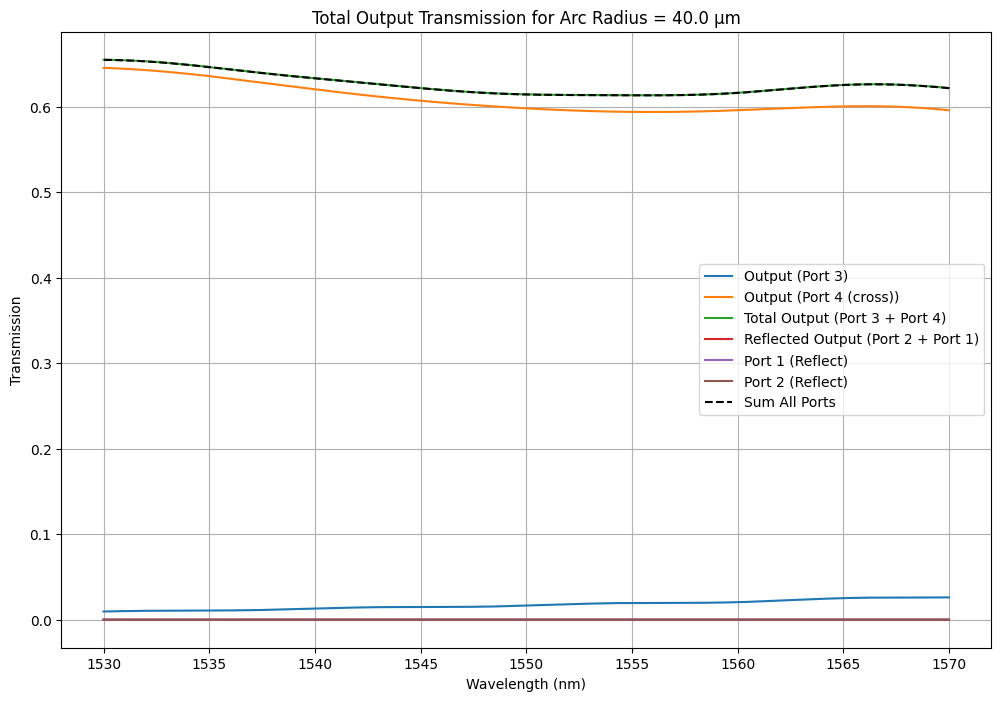

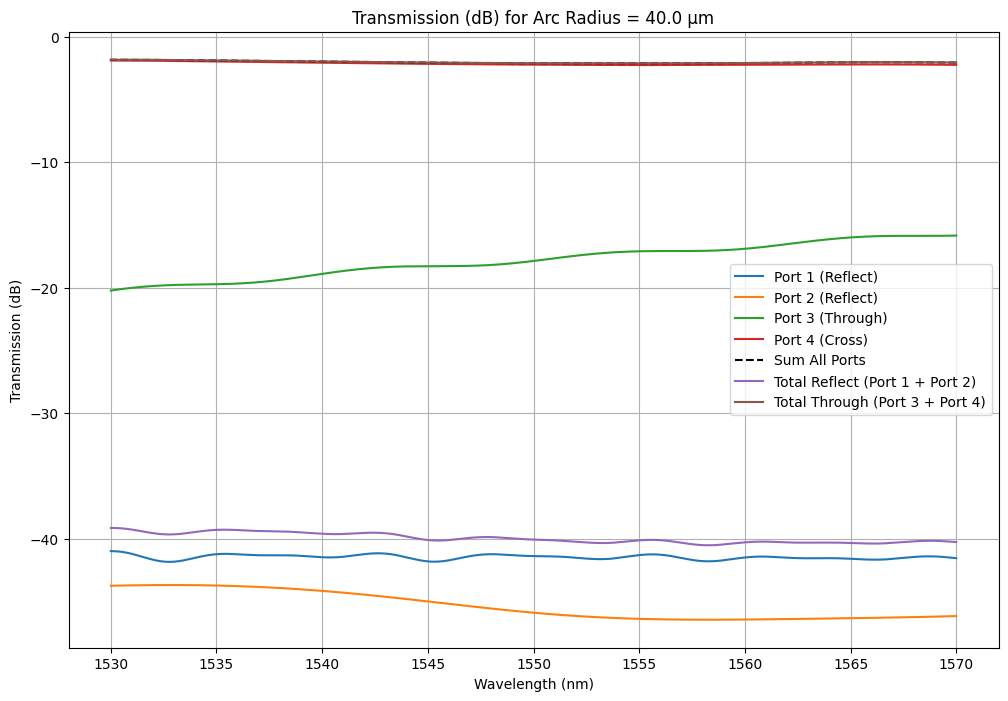

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius40.00um_Tx.txt
R=50µm | η=96.95% | Loss=0.85dB| eta variation=3.46%


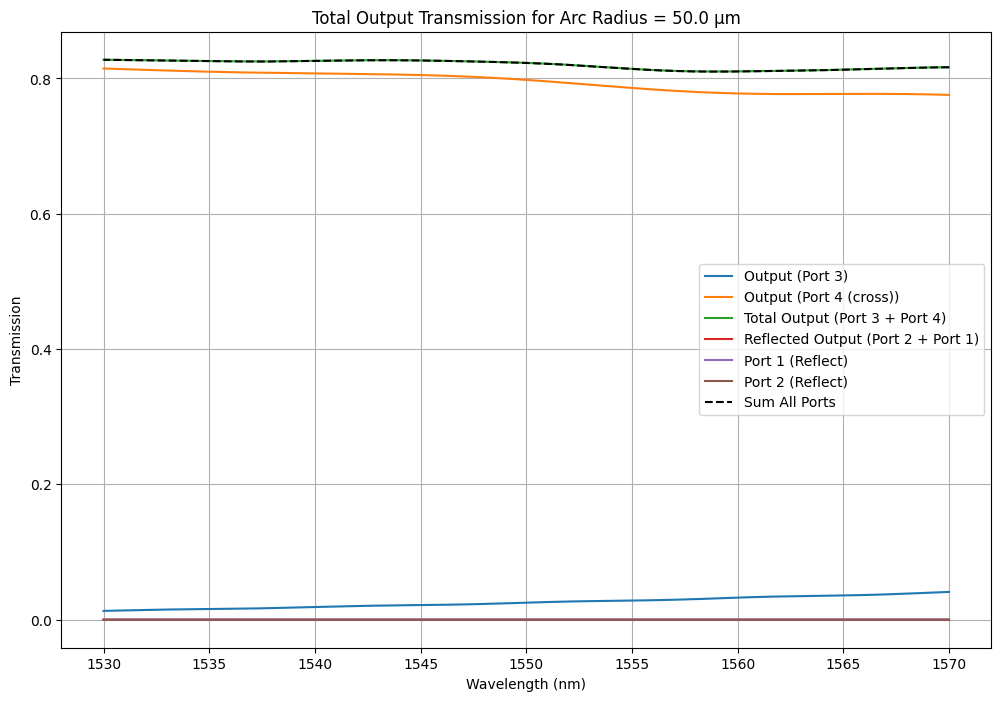

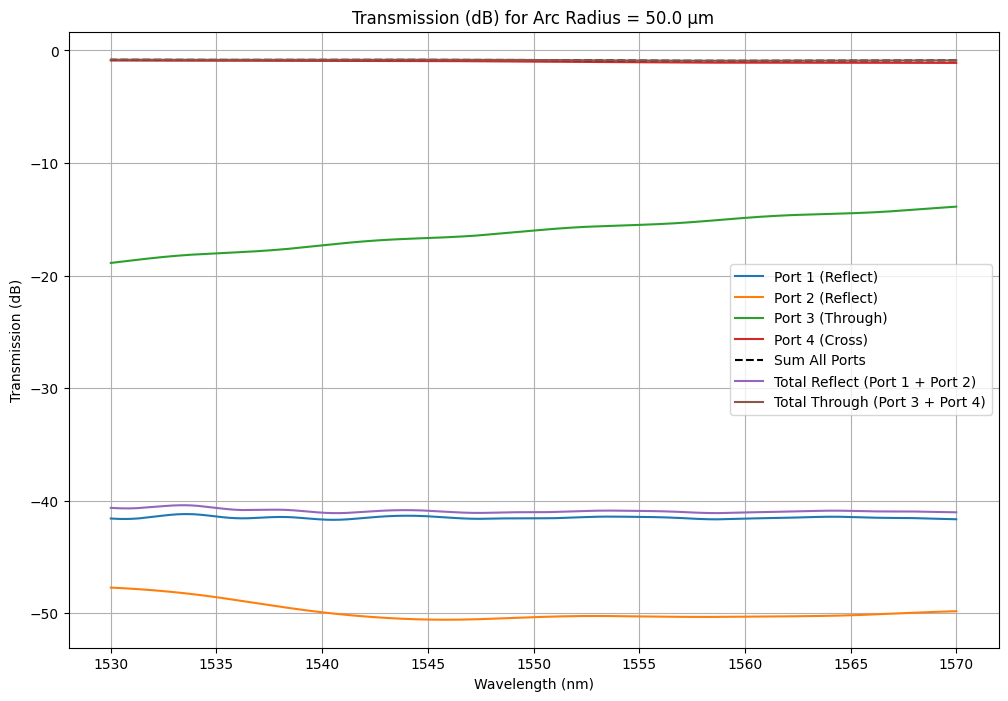

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius50.00um_Tx.txt
R=60µm | η=96.66% | Loss=0.48dB| eta variation=3.63%


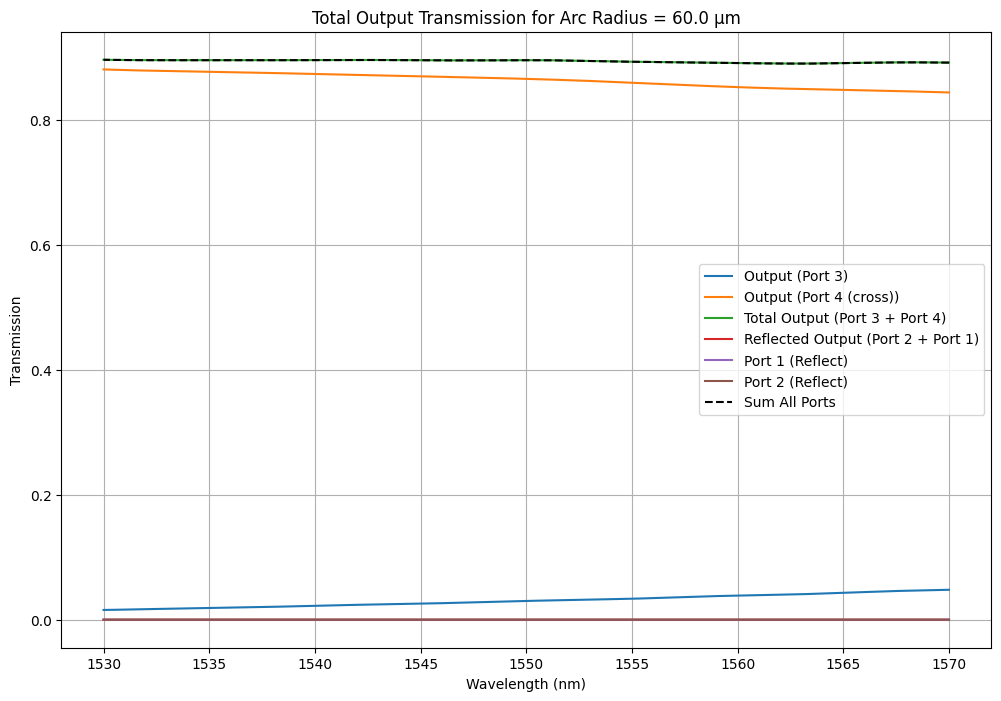

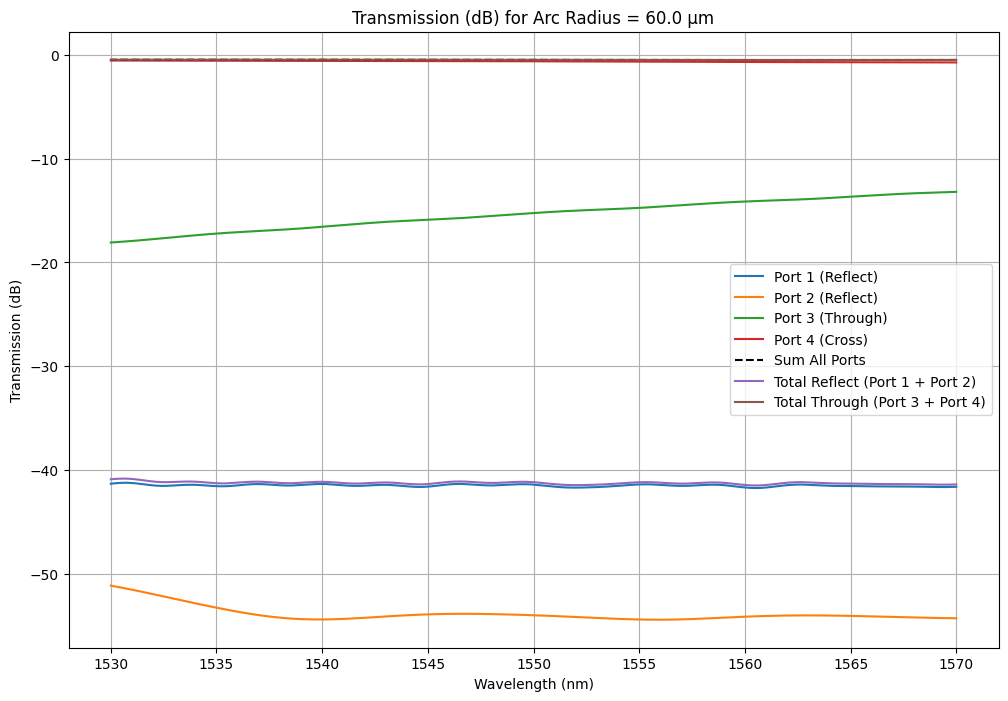

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius60.00um_Tx.txt
R=70µm | η=96.38% | Loss=0.34dB| eta variation=3.80%


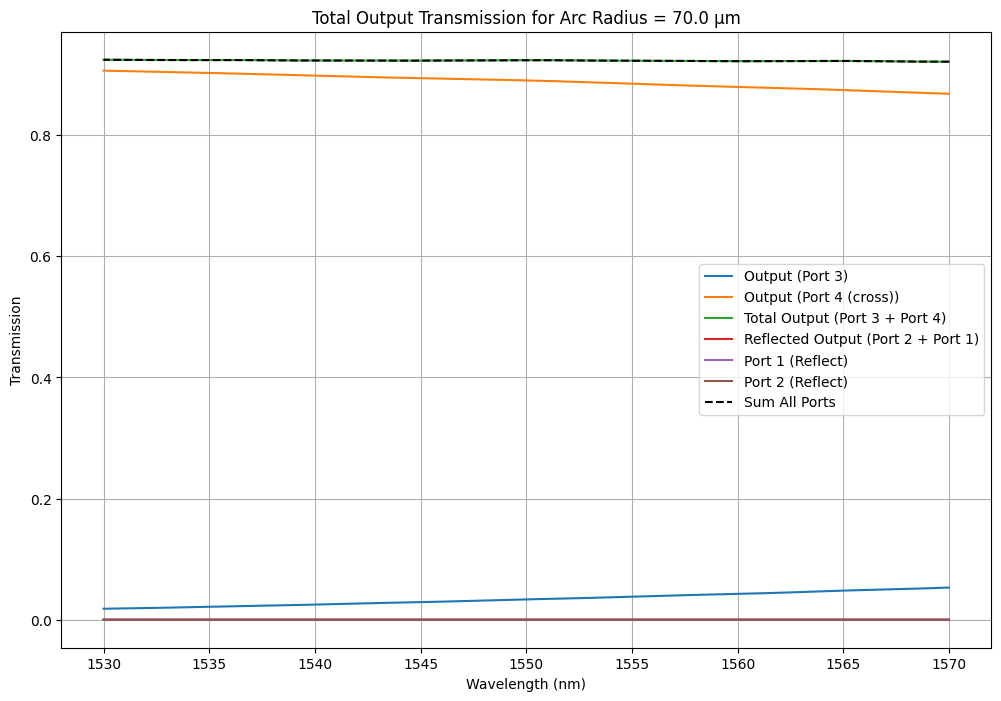

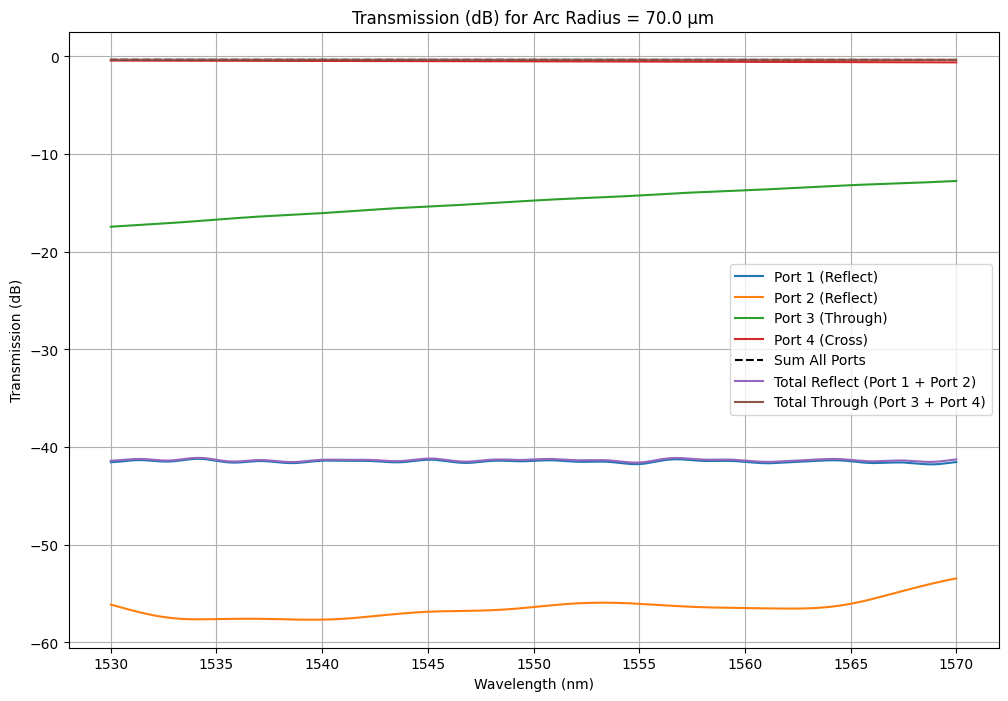

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius70.00um_Tx.txt
R=80µm | η=96.09% | Loss=0.28dB| eta variation=4.04%


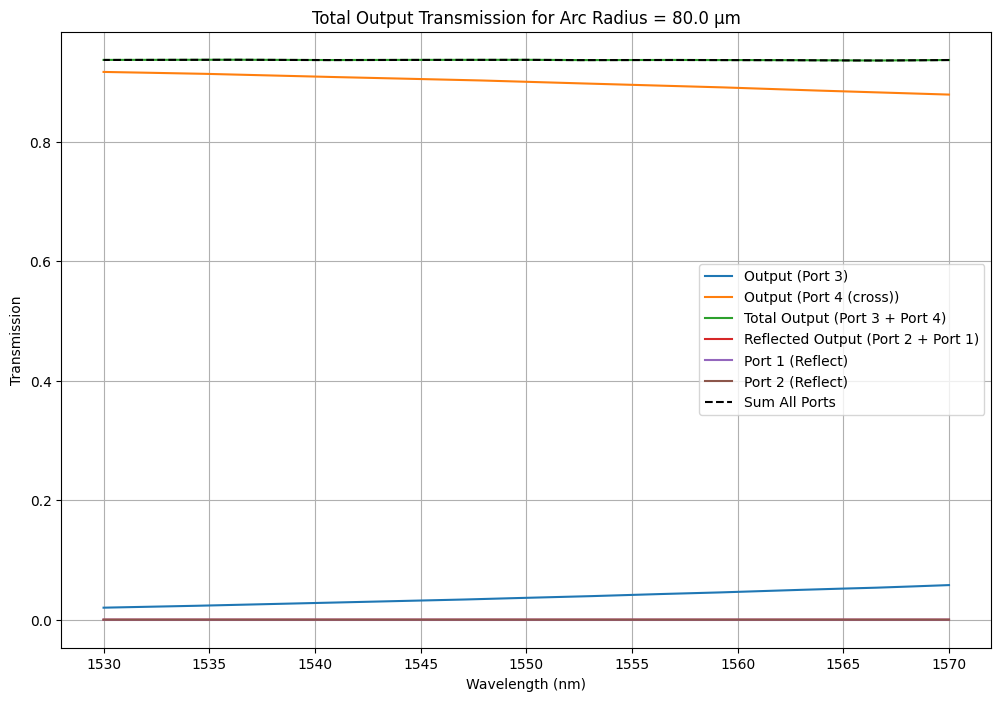

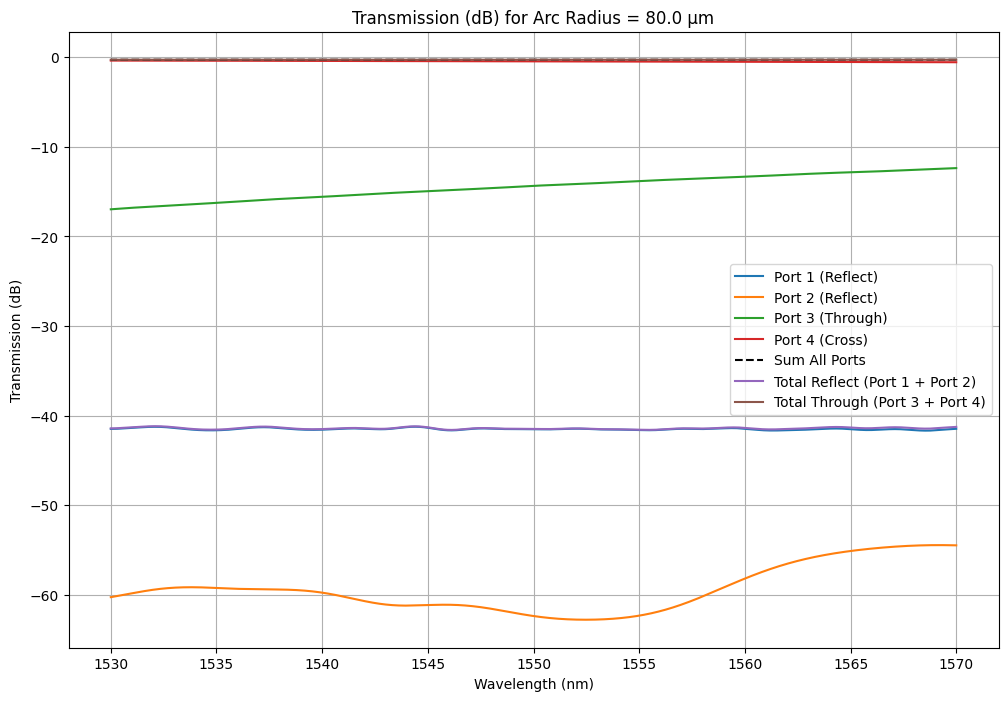

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius80.00um_Tx.txt
R=90µm | η=95.78% | Loss=0.25dB| eta variation=4.19%


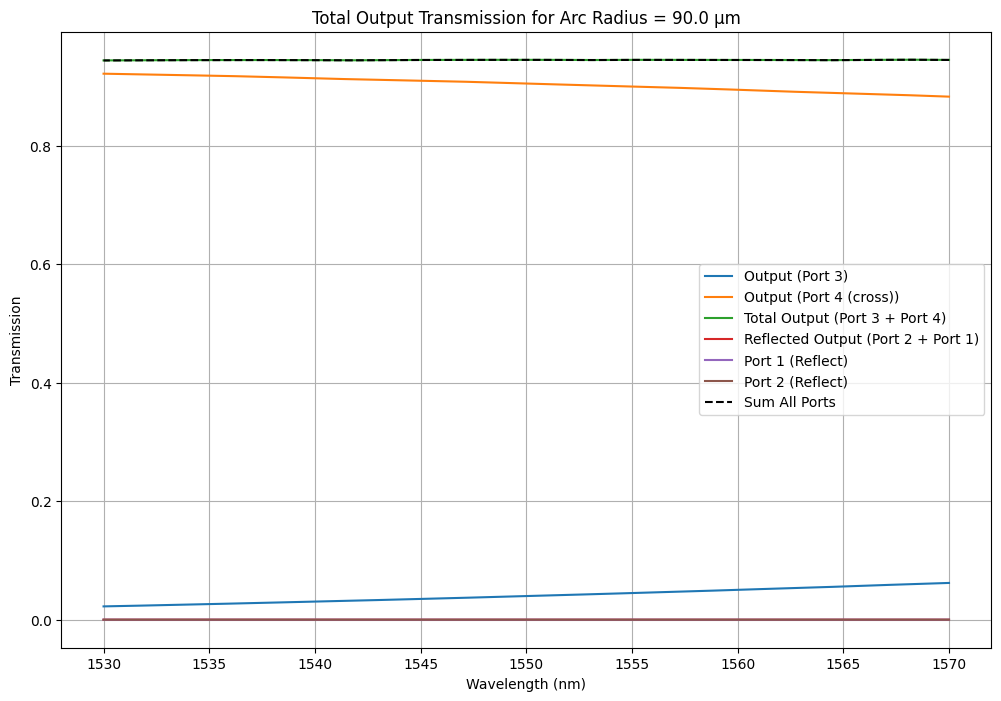

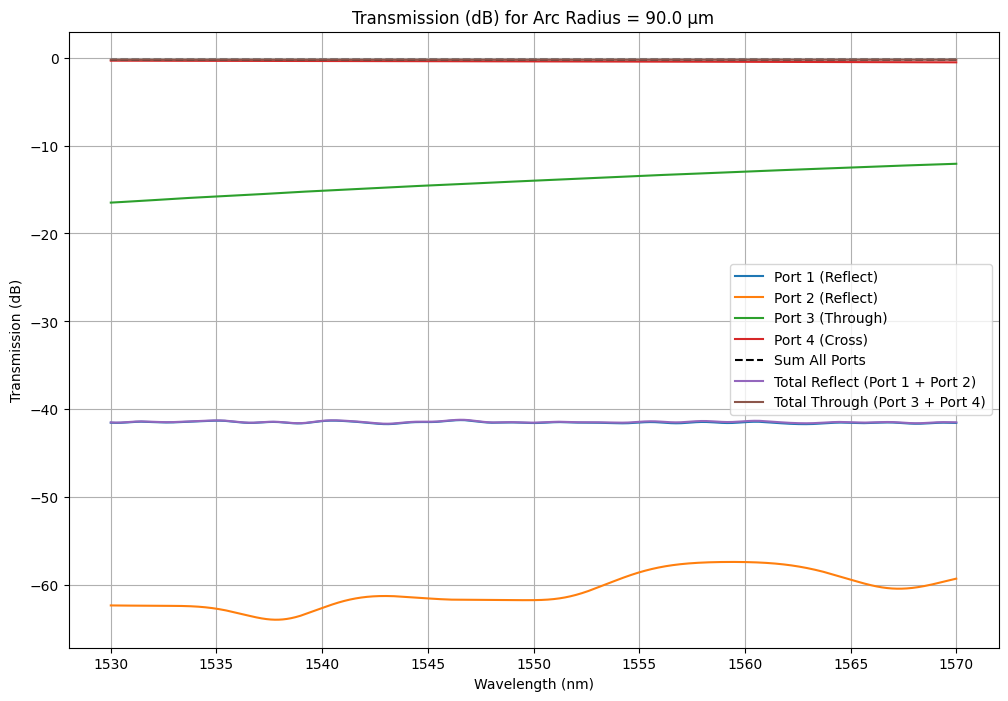

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius90.00um_Tx.txt
R=100µm | η=95.44% | Loss=0.22dB| eta variation=4.37%


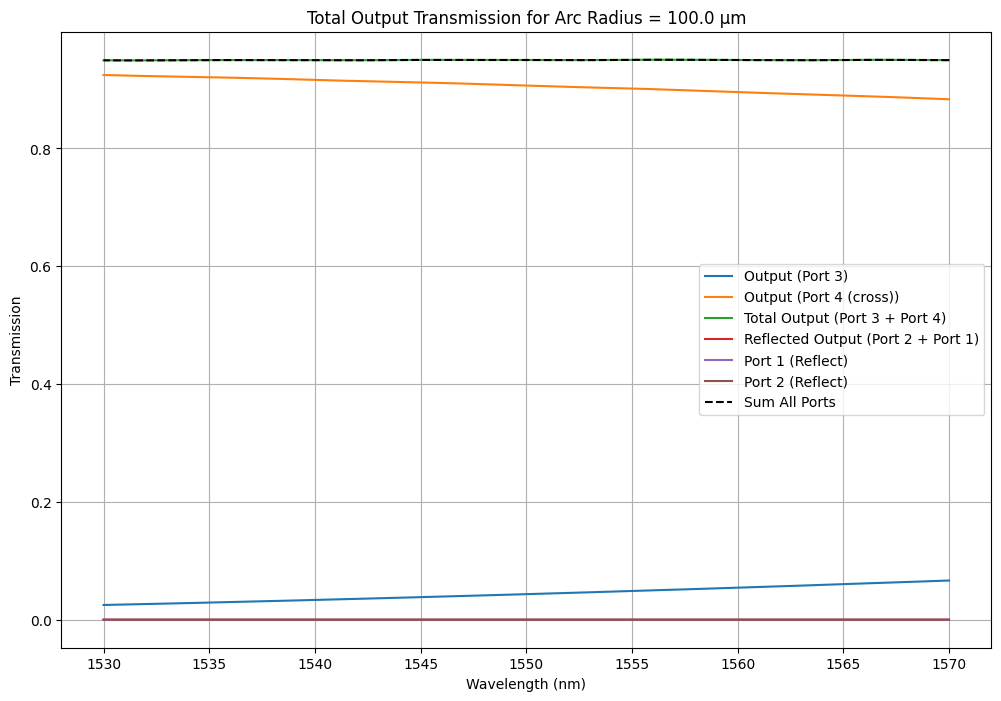

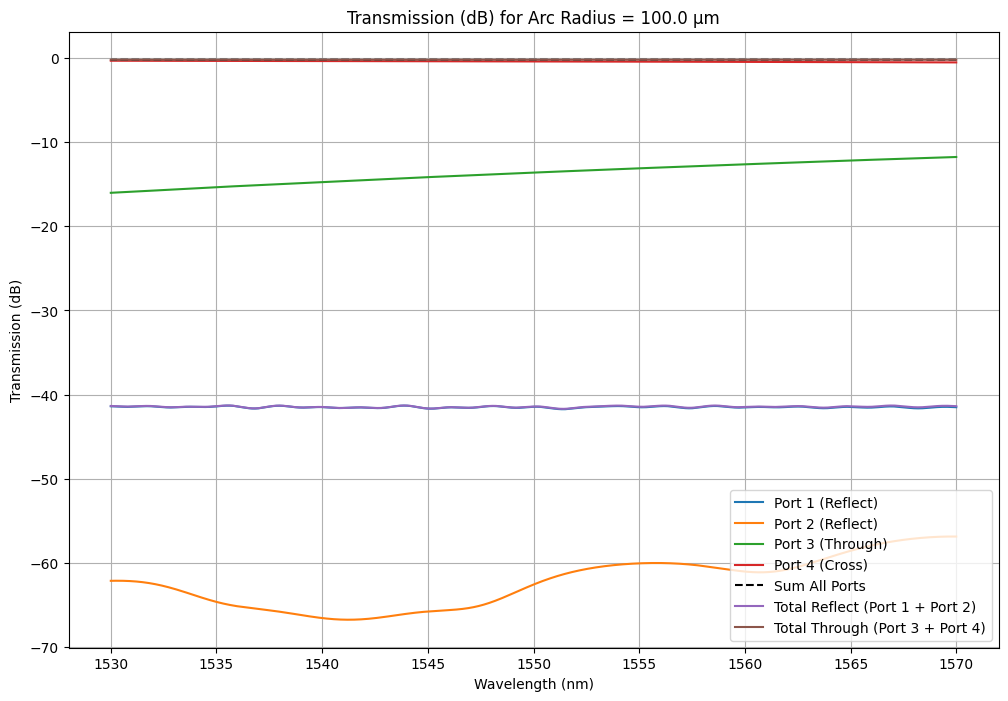

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler\Data_DirectionalCoupler_radii_sweep_radius100.00um_Tx.txt
   ArcRadius  eta_1550  loss_dB_1550  eta_variation
0    0.00004  0.973444      2.114110       0.027321
1    0.00005  0.969487      0.845587       0.034550
2    0.00006  0.966615      0.476562       0.036307
3    0.00007  0.963835      0.343447       0.038047
4    0.00008  0.960878      0.281904       0.040352
5    0.00009  0.957756      0.245644       0.041870
6    0.00010  0.954352      0.222348       0.043690


In [ ]:
radii = [40E-6,50E-6, 60E-6,70E-6, 80E-6,90E-6,100E-6]

radii_sweep_results = []

for r in radii:
    f.switchtolayout()
    f.selectall()
    f.delete()

    ArcRadius = r

    #------------------------------------------------------------
    # STRUCTURE GROUP : Directional Coupler
    #------------------------------------------------------------

    group_name = "Directional Coupler Group"
    f.addstructuregroup()
    f.set("name", group_name)
    f.set("construction group", 1)
    f.set("x", 0)
    f.set("y", 0)
    f.set("z", 0)

    # ADD USER PROPERTIES
    f.adduserprop("Width",          2, Width)
    f.adduserprop("Height",         2, Height)
    f.adduserprop("Gap",            2, Gap)
    f.adduserprop("LengthIn",       2, XLength)
    f.adduserprop("VerticalLength", 2, YLength)
    f.adduserprop("CouplingLength", 2, CouplingLength)
    f.adduserprop("ArcRadius",      2, ArcRadius)
    f.adduserprop("Index",          0, Index)
    f.adduserprop("Material",       5, Material)

    # Convert vertices for top and bottom arms
    def vertices_to_str(poly):
        return "[" + "; ".join(f"{x}, {y}" for x, y in poly) + "]"

    top, bot = directional_coupler(gap=Gap, width=Width, length_in=XLength, vertical_length=YLength,
                                coupling_length=CouplingLength, arc_radius=ArcRadius)
    top_str = vertices_to_str(top)
    bot_str = vertices_to_str(bot)

    #------------------------------------------------------------
    # GEOMETRY SETUP SCRIPT
    #------------------------------------------------------------

    setup_script = f"""
    # Top U-bend arm
    addpoly;
    set('name', 'top_arm');
    set('vertices', {top_str});

    # Bottom U-bend arm
    addpoly;
    set('name', 'bot_arm');
    set('vertices', {bot_str});

    # Assign materials & finalize
    selectall;
    if (Material == '<Object defined dielectric>') {{
        set('index', Index);
    }} else {{
        set('material', Material);
    }}
    set('z min', 0);
    set('z max', Height);
    """
    f.set("script", setup_script)

    #------------------------------------------------------------
    # VarFDTD
    #------------------------------------------------------------
    margin = (LambdaStop+LambdaStart)/2
    all_points = np.vstack([top, bot])
    x_span = (all_points[:,0].max() - all_points[:,0].min()) - margin
    y_span = (all_points[:,1].max() - all_points[:,1].min()) +2*margin
    f.addvarfdtd()
    f.set("simulation time", SimulationTime) 
    f.set("x0",0)              # mode position (that green arrow)
    f.set("y0",Gap/2 + Width/2)
    f.set("x", 0)                    # Centered in X
    f.set("x span", x_span)    # Cover full structure
    f.set("y", 0)                    # Centered in Y
    f.set("y span", y_span)  # Cover full waveguide & ring
    f.set("z", Height / 2)           # Centered in Z
    f.set("z span", 8*Height)        # Cover height of the structure
    f.set("background material",BackgroundMaterial)
    f.set("set simulation bandwidth",1)
    f.set("bandwidth",'broadband')
    f.set("simulation wavelength min", LambdaStart)
    f.set("simulation wavelength max", LambdaStop)
    f.set("auto shutoff min",1E-5)

    # Boundary Conditions
    f.set("x min bc", "PML")
    f.set("x max bc", "PML")
    f.set("y min bc", "PML")
    f.set("y max bc", "PML")
    f.set("z min bc", "PML")
    f.set("z max bc", "PML")

    #------------------------------------------------------------
    # Source
    #------------------------------------------------------------

    f.addmodesource()
    f.set("name", "ModeSource")
    f.set("x", -x_span/2+(LambdaStart*2.0))  # Aligned with the right ring
    f.set("y",  YLength+2*ArcRadius+Gap + Width/2)
    f.set("y span", 2 * Width)
    f.set("use relative coordinates", 1)
    f.set("injection axis", "x-axis")
    f.set("direction", "Forward")
    f.set("amplitude", 1.0)
    f.set("phase", 0)
    f.set("mode selection", "fundamental mode")
    f.set("set wavelength", 1)
    f.set("wavelength start", LambdaStart)
    f.set("wavelength stop", LambdaStop)

    #------------------------------------------------------------
    # Monitors 
    #------------------------------------------------------------

    # port 1 
    f.adddftmonitor()
    f.set("name", "Port1")
    f.set("monitor type", "Linear Y")
    f.set("x", -x_span/2+(LambdaStart*0.5))  # Aligned with the right ring
    f.set("y",  (YLength+2*ArcRadius+Gap + Width/2))
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # port 2 
    f.adddftmonitor()
    f.set("name", "Port2")
    f.set("monitor type", "Linear Y")
    f.set("x", -x_span/2+XLength/6)  # Aligned with the right ring
    f.set("y",  -(YLength+2*ArcRadius+Gap + Width/2))
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # port 3
    f.adddftmonitor()
    f.set("name", "Port3")
    f.set("monitor type", "Linear Y")
    f.set("x", x_span/2 - XLength/6)  # Aligned with the right ring
    f.set("y",  YLength+2*ArcRadius+Gap + Width/2)
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # port 4
    f.adddftmonitor()
    f.set("name", "Port4")
    f.set("monitor type", "Linear Y")
    f.set("x", x_span/2 - XLength/6)  # Aligned with the right ring
    f.set("y",  -(YLength+2*ArcRadius+Gap + Width/2))
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)  

    # Field Monitor PORT
    # f.adddftmonitor()
    # f.set("name", "Field Monitor")
    # f.set("monitor type", "2D Z-normal")
    # f.set("x", 0)                    # Centered in X
    # f.set("x span", 2*(ArcRadius/2+CouplingLength+LambdaStop))    # Cover full structure
    # f.set("y", 0)                    # Centered in Y
    # f.set("y span", 10*Width)  # Cover full waveguide & ring
    # f.set("z", Height / 2)  # Centered in Z
    # f.set("override global monitor settings", 1)
    # f.set('use wavelength spacing',1)
    # f.set('wavelength center', 0.75E-6)  # Center wavelength
    # f.set('wavelength span', 0.008E-6) 
    # f.set("frequency points", round((LambdaStop - LambdaStart) * 1E9))

    #------------------------------------------------------------
    # Run
    #------------------------------------------------------------
    f.run()

    #------------------------------------------------------------
    # Save Data
    #------------------------------------------------------------
    T_Port1 = f.getresult("Port1", "T")
    T_port2 = f.getresult("Port2", "T")
    T_port3 = f.getresult("Port3", "T")
    T_port4 = f.getresult("Port4", "T")

    Tx_Reflect_1 = T_Port1["T"].flatten()
    Tx_Reflect_2 = T_port2["T"].flatten()
    Tx_Through = T_port3["T"].flatten()
    Tx_Cross = T_port4["T"].flatten()
    Wavelenghth = T_port2["lambda"].flatten()

    Tx_total_out = Tx_Through + Tx_Cross 
    Tx_total_reflect = Tx_Reflect_2 + Tx_Reflect_1

    # Matric at 1550 nm ----------------------------------
    idx_1550 = np.argmin(np.abs(Wavelenghth - 1550e-9))
    eta_1550 = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
    loss_dB_1550 = -10 * np.log10(Tx_total_out[idx_1550])

    # 3dB bandwidth
    eta_array = Tx_Cross / (Tx_Cross + Tx_Through)
    eta_variation = eta_array.max() - eta_array.min()

    print(f"R={ArcRadius*1e6:.0f}µm | η={eta_1550:.2%} | Loss={loss_dB_1550:.2f}dB" 
        f"| eta variation={eta_variation:.2%}")
    #------------------------------------------------------------

    plt.figure(figsize=(12,8))
    plt.plot(Wavelenghth*1E9, Tx_Through, label='Output (Port 3)')
    plt.plot(Wavelenghth*1E9, Tx_Cross, label='Output (Port 4 (cross))')
    plt.plot(Wavelenghth*1E9, Tx_total_out, label='Total Output (Port 3 + Port 4)')
    plt.plot(Wavelenghth*1E9, Tx_total_reflect, label='Reflected Output (Port 2 + Port 1)')
    plt.plot(Wavelenghth*1E9, Tx_Reflect_1, label='Port 1 (Reflect)')
    plt.plot(Wavelenghth*1E9, Tx_Reflect_2, label='Port 2 (Reflect)')
    plt.plot(Wavelenghth*1E9, Tx_total_out + Tx_total_reflect, label='Sum All Ports', linestyle='--', color='black')
    plt.title(f'Total Output Transmission for Arc Radius = {ArcRadius*1E6} µm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12,8))
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1)), label='Port 1 (Reflect)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2)), label='Port 2 (Reflect)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through)), label='Port 3 (Through)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Cross)), label='Port 4 (Cross)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1 + Tx_Reflect_2 + Tx_Through + Tx_Cross)), label='Sum All Ports', linestyle='--', color='black')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2 + Tx_Reflect_1)), label='Total Reflect (Port 1 + Port 2)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through + Tx_Cross)), label='Total Through (Port 3 + Port 4)')
    plt.title(f'Transmission (dB) for Arc Radius = {ArcRadius*1E6} µm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission (dB)')
    plt.legend()
    plt.grid()
    plt.show()

    #update results list
    radii_sweep_results.append({
        "ArcRadius": ArcRadius,
        "eta_1550": eta_1550,
        "loss_dB_1550": loss_dB_1550,
        "eta_variation": eta_variation
    })

    header = f"""Gap={Gap*1e9:.2f}nm Width={Width*1e9:.2f}nm Height={Height*1e9:.2f}nm
    CouplingLength={CouplingLength*1e6:.2f}um ArcRadius={ArcRadius*1e6:.2f}um
    Material={Material} SimTime={SimulationTime*1e12:.2f}ps
    eta_1550={eta_1550:.4f} loss_1550_dB={loss_dB_1550:.2f}dB eta_variation={eta_variation:.4f}
    Wavelength(um) Transmission_Cross Transmission_Through Transmission_Reflect_1 Transmission_Reflect_2"""

    filename = Path(r'D:\Ring_MIT_Sid_chip\results_data\Data_directional_coupler')/f"Data_{LumFileName.removesuffix('.lms')}_radius{ArcRadius*1E6:.2f}um_Tx.txt"
    data = np.column_stack([Wavelenghth*1E6, Tx_Cross, Tx_Through, Tx_Reflect_1, Tx_Reflect_2])
    np.savetxt(filename, data, header=header)

    print(f"Data saved to {filename}")

df = pd.DataFrame(radii_sweep_results)
print(df)